# Step 0: Sensor Data Exploration
## Upstairs vs. Downstairs

**NOTE:** this recoding did not go very well, something is worn with the watch labels. See `data-analysis-walkin` notebook for better comparsion


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print('Ready!')

Ready!


## 1. Load Data

Update the paths below to point to your two recording folders.

In [3]:
# === UPDATE THESE PATHS ===
DEFAULT_DIR = Path('data/upstairs-downstairs/default/')    # folder with default recording CSVs
ZOO_DIR = Path('data/upstairs-downstairs/sensorzoo/')      # folder with sensor zoo recording CSVs

def load_csv(folder, name):
    """Load a CSV file from a recording folder. Returns None if file is empty."""
    path = folder / name
    if not path.exists():
        print(f'  [SKIP] {name} not found in {folder}')
        return None
    try:
        df = pd.read_csv(path)
        if df.empty:
            print(f'  [EMPTY] {name}')
            return None
        return df
    except Exception as e:
        print(f'  [ERROR] {name}: {e}')
        return None

# Core sensor files
SENSOR_FILES = [
    'Accelerometer.csv', 'AccelerometerUncalibrated.csv', 'TotalAcceleration.csv',
    'Gravity.csv', 'Gyroscope.csv', 'GyroscopeUncalibrated.csv',
    'Orientation.csv', 'Magnetometer.csv', 'MagnetometerUncalibrated.csv',
    'Compass.csv', 'Barometer.csv', 'Pedometer.csv', 'Location.csv',
    'Annotation.csv', 'Activity.csv', 'Metadata.csv',
    'WatchAccelerometer.csv', 'WatchGyroscope.csv', 'WatchOrientation.csv',
    'WatchBarometer.csv', 'WatchGravity.csv', 'WatchMagnetometer.csv',
    'WatchTotalAcceleration.csv', 'WatchLocation.csv',
    'WiFi.csv', 'Network.csv'
]

print('=== Loading DEFAULT recording ===')
default = {f: load_csv(DEFAULT_DIR, f) for f in SENSOR_FILES}
print(f'\n=== Loading SENSOR ZOO recording ===')
zoo = {f: load_csv(ZOO_DIR, f) for f in SENSOR_FILES}

=== Loading DEFAULT recording ===
  [SKIP] WatchLocation.csv not found in data\upstairs-downstairs\default

=== Loading SENSOR ZOO recording ===
  [SKIP] WatchLocation.csv not found in data\upstairs-downstairs\sensorzoo


In [4]:
# Quick overview: how many rows per sensor?
summary = []
for f in SENSOR_FILES:
    d_rows = len(default[f]) if default[f] is not None else 0
    z_rows = len(zoo[f]) if zoo[f] is not None else 0
    summary.append({'sensor': f.replace('.csv',''), 'default_rows': d_rows, 'zoo_rows': z_rows})

pd.DataFrame(summary).set_index('sensor')

,default_rows,zoo_rows
sensor,,
Accelerometer,1536,1415
AccelerometerUncalibrated,1529,1411
TotalAcceleration,1529,1412
Gravity,1535,1415
Gyroscope,1533,1414
GyroscopeUncalibrated,1531,1413
Orientation,1486,1413
Magnetometer,2835,2617
MagnetometerUncalibrated,2830,2614


## 2. Helper Functions

In [5]:
def get_annotations(data_dict):
    """Extract annotation timestamps as a dict of {text: seconds_elapsed}."""
    ann = data_dict.get('Annotation.csv')
    if ann is None or ann.empty:
        return {}
    return dict(zip(ann['text'], ann['seconds_elapsed']))

def add_activity_shading(ax, annotations, max_time):
    """Add colored background shading based on annotations."""
    colors = {'Upstairs': '#2ecc71', 'Downstairs': '#3498db', 'upstairs': '#2ecc71', 'downstairs': '#3498db'}
    sorted_anns = sorted(annotations.items(), key=lambda x: x[1])
    for i, (text, start) in enumerate(sorted_anns):
        end = sorted_anns[i+1][1] if i+1 < len(sorted_anns) else max_time
        color = colors.get(text, '#95a5a6')
        ax.axvspan(start, end, alpha=0.15, color=color, label=text)
    # Add annotation lines
    for text, t in annotations.items():
        ax.axvline(x=t, color='red', linestyle='--', alpha=0.5, linewidth=1)

def plot_xyz(df, title, annotations=None, cols=['x','y','z']):
    """Plot x, y, z columns over seconds_elapsed."""
    if df is None:
        print(f'No data for: {title}')
        return
    fig, ax = plt.subplots(figsize=(14, 4))
    t = df['seconds_elapsed']
    for c in cols:
        if c in df.columns:
            ax.plot(t, df[c], label=c, alpha=0.8, linewidth=0.7)
    if annotations:
        add_activity_shading(ax, annotations, t.max())
    ax.set_xlabel('Time (seconds)')
    ax.set_title(title)
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

def plot_comparison(df_default, df_zoo, col, title, annotations_d=None, annotations_z=None):
    """Side-by-side comparison of default vs zoo for a single column."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    if df_default is not None and col in df_default.columns:
        ax1.plot(df_default['seconds_elapsed'], df_default[col], linewidth=0.7)
        if annotations_d:
            add_activity_shading(ax1, annotations_d, df_default['seconds_elapsed'].max())
    ax1.set_title(f'{title} — Default')
    ax1.set_xlabel('Time (s)')
    
    if df_zoo is not None and col in df_zoo.columns:
        ax2.plot(df_zoo['seconds_elapsed'], df_zoo[col], linewidth=0.7, color='tab:orange')
        if annotations_z:
            add_activity_shading(ax2, annotations_z, df_zoo['seconds_elapsed'].max())
    ax2.set_title(f'{title} — Sensor Zoo')
    ax2.set_xlabel('Time (s)')
    plt.tight_layout()
    plt.show()

ann_default = get_annotations(default)
ann_zoo = get_annotations(zoo)
print('Default annotations:', ann_default)
print('Zoo annotations:', ann_zoo)

Default annotations: {'Upstairs': 3.429, 'Downstairs': 16.646}
Zoo annotations: {'Upstairs': 2.088000244140625, 'Downstairs': 15.342}


## 3. Phone Accelerometer

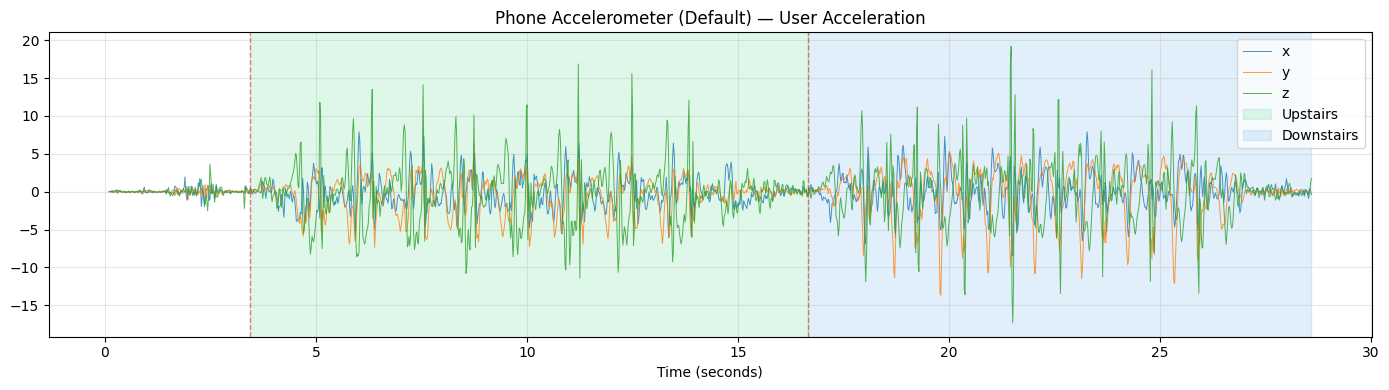

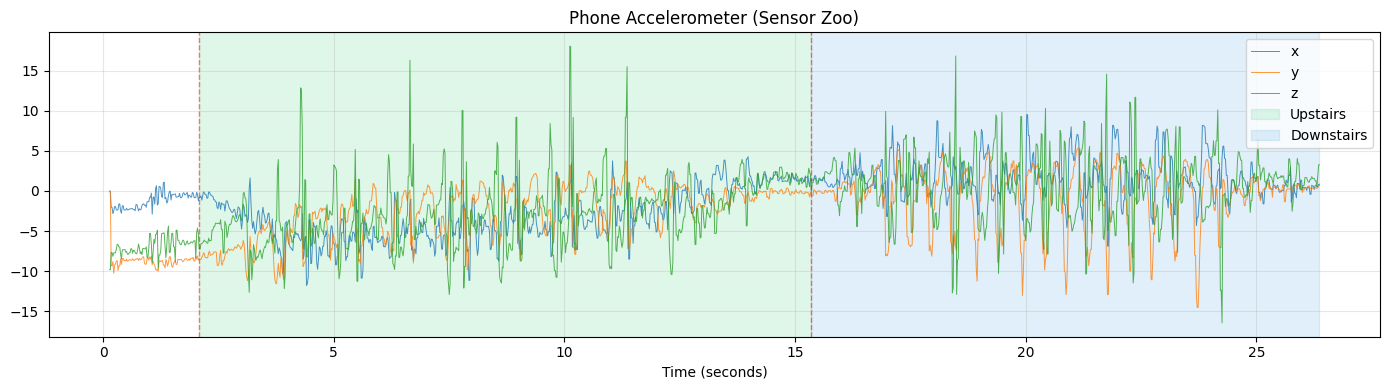

In [6]:
plot_xyz(default['Accelerometer.csv'], 'Phone Accelerometer (Default) — User Acceleration', ann_default)
plot_xyz(zoo['Accelerometer.csv'], 'Phone Accelerometer (Sensor Zoo)', ann_zoo)

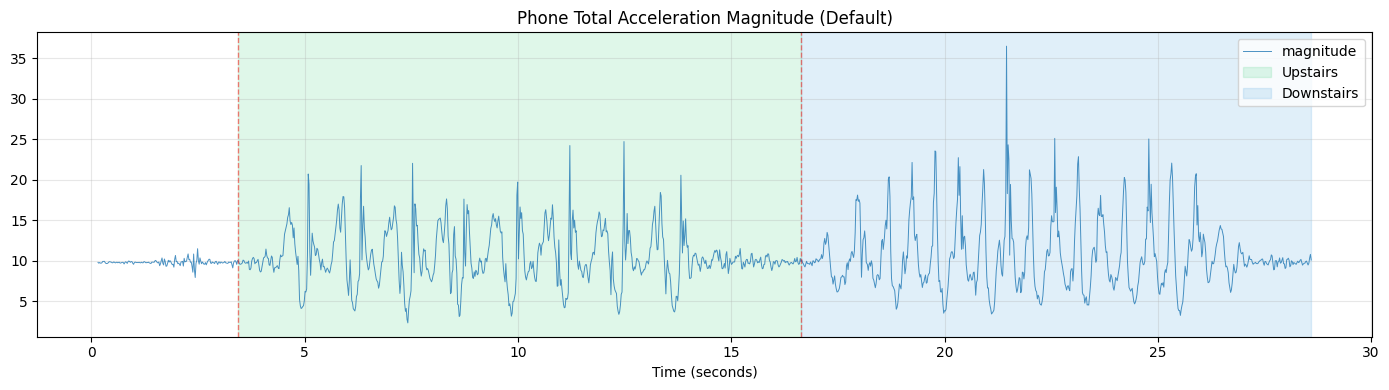

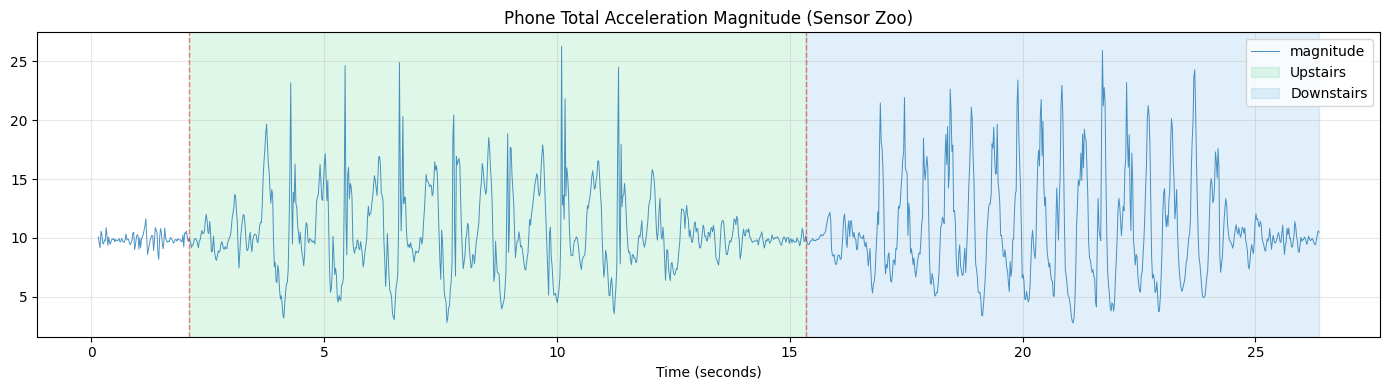

In [7]:
for label, data, ann in [('Default', default, ann_default), ('Sensor Zoo', zoo, ann_zoo)]:
    df = data['TotalAcceleration.csv']
    if df is not None:
        df = df.copy()
        df['magnitude'] = np.sqrt(df['x']**2 + df['y']**2 + df['z']**2)
        plot_xyz(df, f'Phone Total Acceleration Magnitude ({label})', ann, cols=['magnitude'])

## 4. Phone Gyroscope

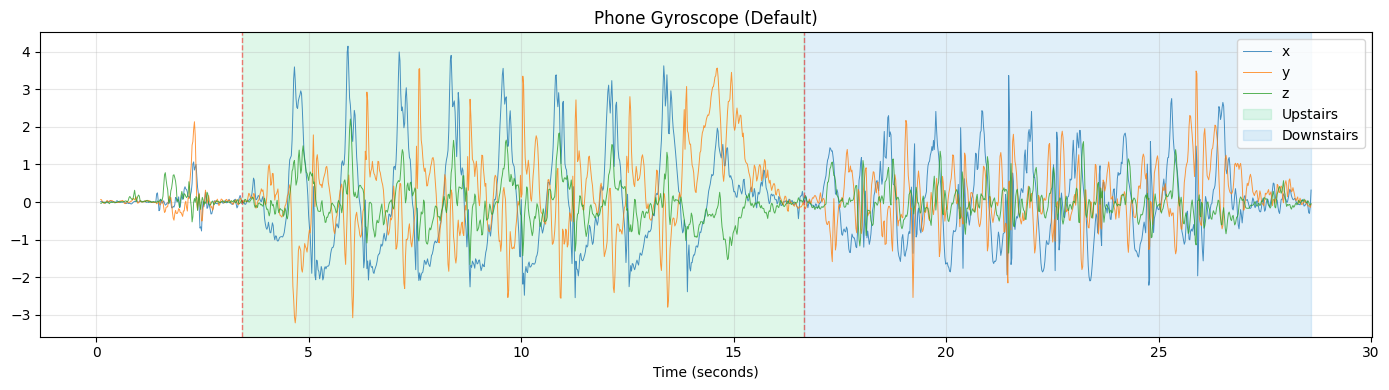

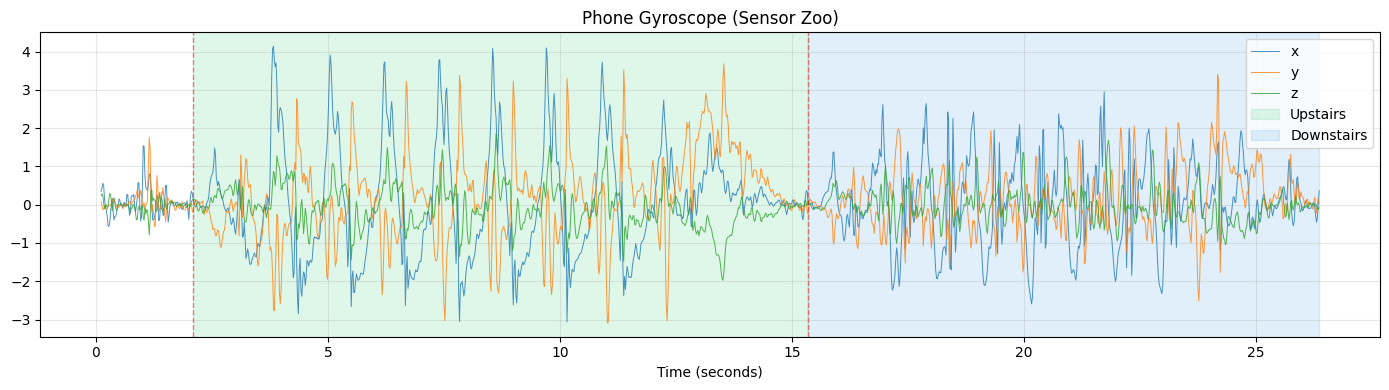

In [8]:
plot_xyz(default['Gyroscope.csv'], 'Phone Gyroscope (Default)', ann_default)
plot_xyz(zoo['Gyroscope.csv'], 'Phone Gyroscope (Sensor Zoo)', ann_zoo)

## 5. Orientation (Quaternion & Euler Angles)

This is where Default (Android OS fusion) vs Sensor Zoo (Madgwick) should differ most.
Compare roll, pitch, yaw between the two.

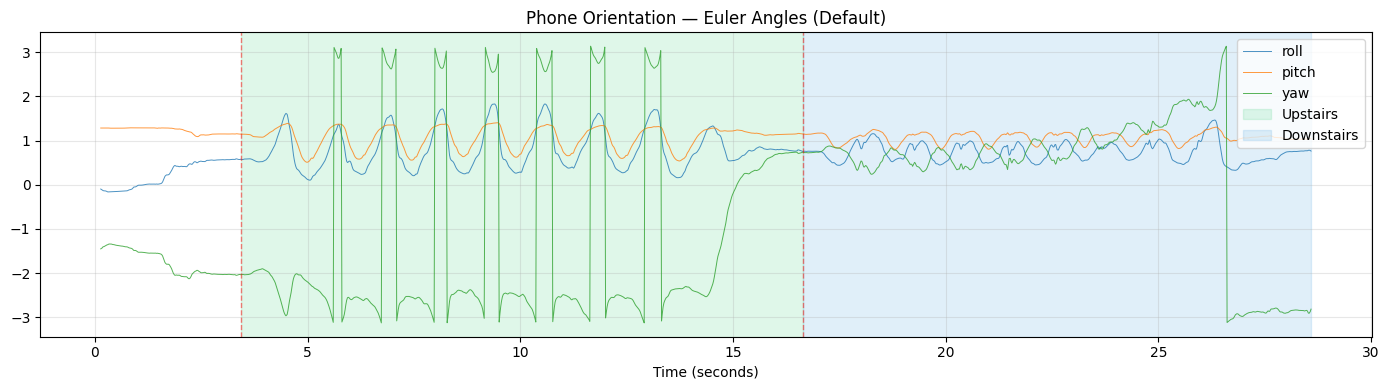

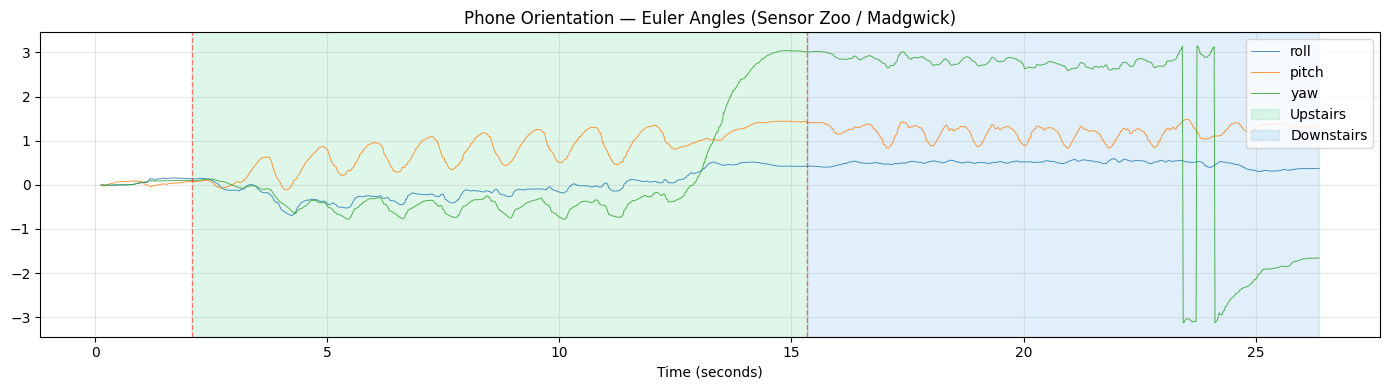

In [9]:
plot_xyz(default['Orientation.csv'], 'Phone Orientation — Euler Angles (Default)', ann_default, cols=['roll', 'pitch', 'yaw'])
plot_xyz(zoo['Orientation.csv'], 'Phone Orientation — Euler Angles (Sensor Zoo / Madgwick)', ann_zoo, cols=['roll', 'pitch', 'yaw'])

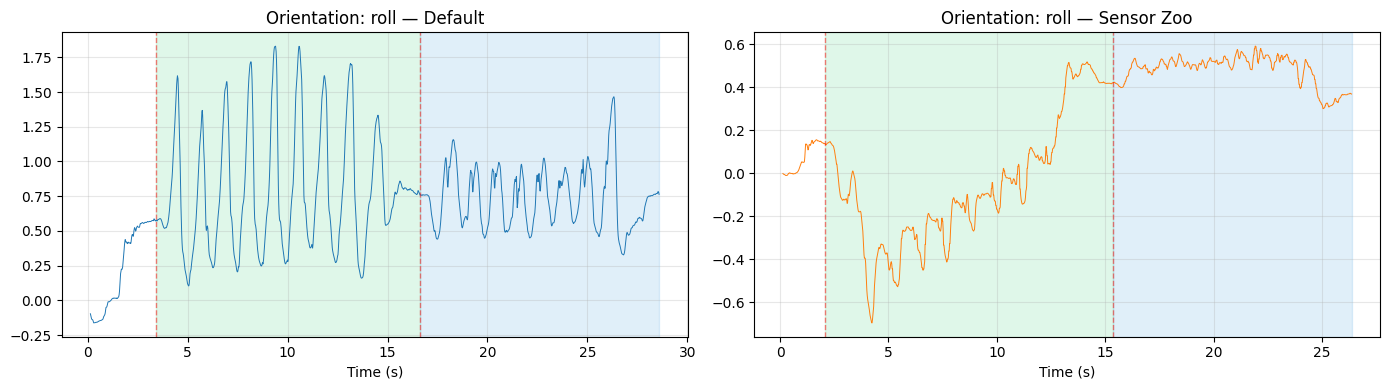

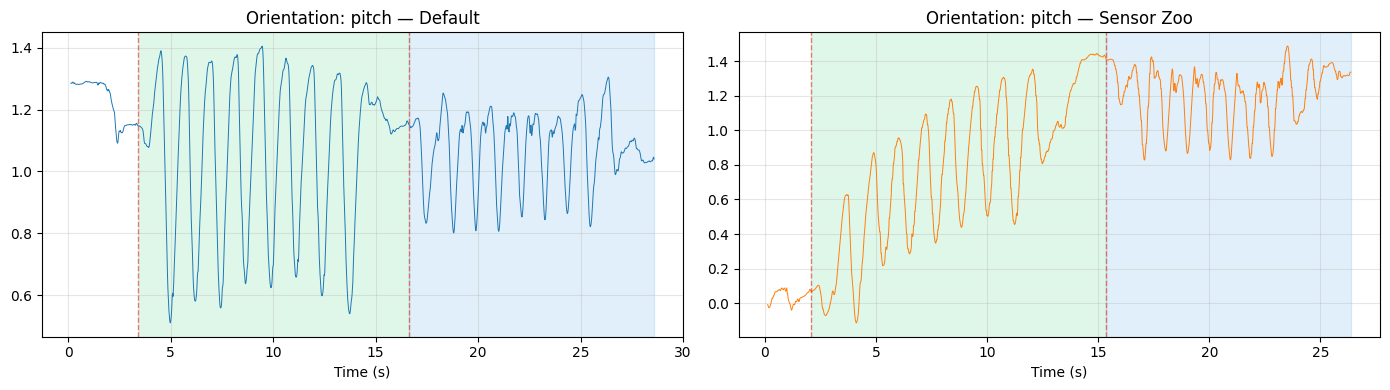

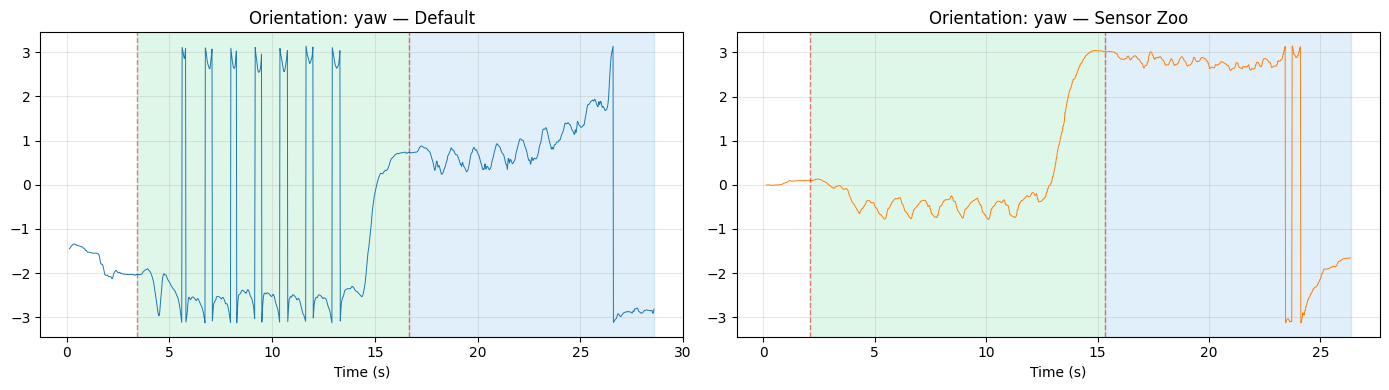

In [10]:
# Side-by-side for each angle
for angle in ['roll', 'pitch', 'yaw']:
    plot_comparison(default['Orientation.csv'], zoo['Orientation.csv'], angle,
                    f'Orientation: {angle}', ann_default, ann_zoo)

## 6. Barometer (Altitude)

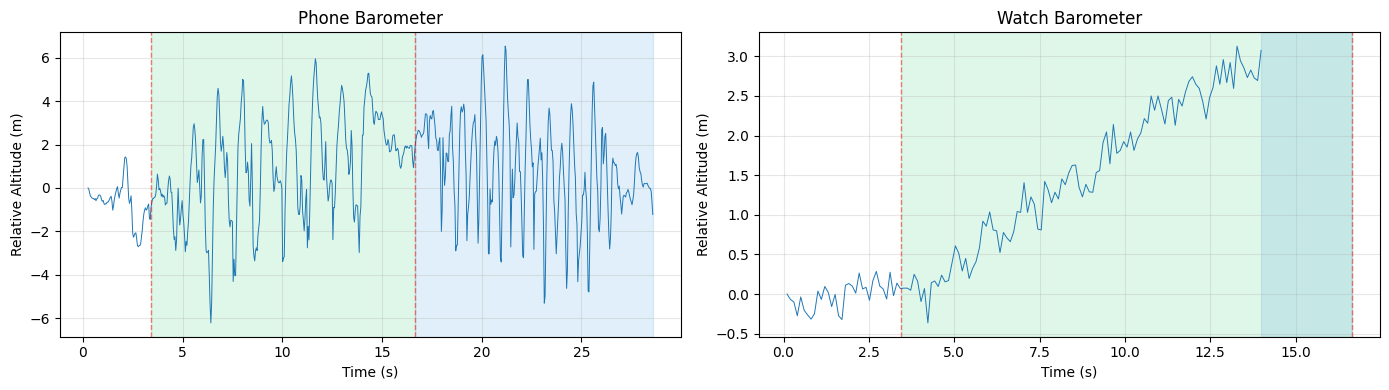

In [11]:
##### plot_xyz(default['Barometer.csv'], 'Phone Barometer (Default)', ann_default, cols=['relativeAltitude', 'pressure'])

# Phone vs Watch barometer
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
for ax, key, title in [(ax1, 'Barometer.csv', 'Phone Barometer'), (ax2, 'WatchBarometer.csv', 'Watch Barometer')]:
    df = default[key]
    if df is not None:
        ax.plot(df['seconds_elapsed'], df['relativeAltitude'], linewidth=0.7)
        if ann_default:
            add_activity_shading(ax, ann_default, df['seconds_elapsed'].max())
    ax.set_title(title)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Relative Altitude (m)')
plt.tight_layout()
plt.show()

## 7. Compass / Heading

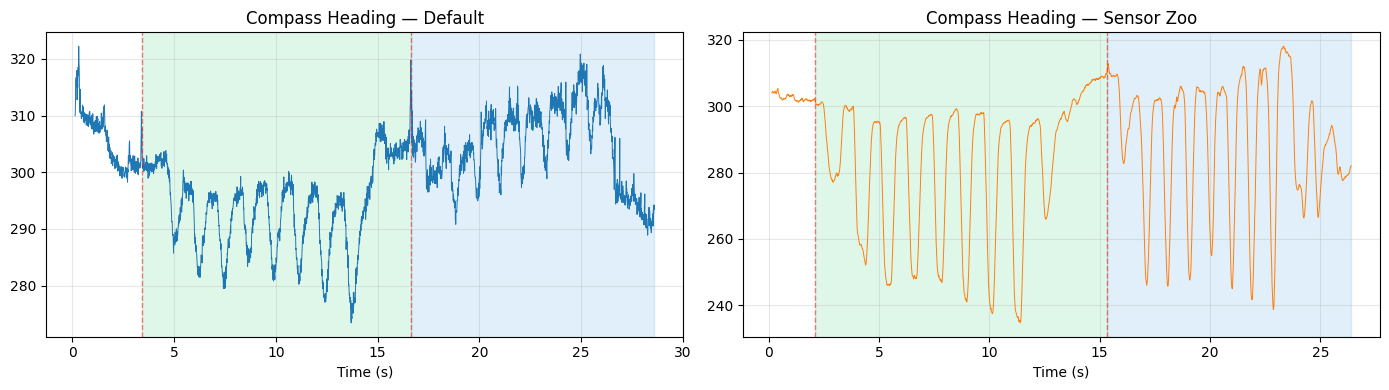

In [12]:
plot_comparison(default['Compass.csv'], zoo['Compass.csv'], 'magneticBearing',
                'Compass Heading', ann_default, ann_zoo)

## 8. Pedometer / Step Counter

Compare step counts between Default (Android built-in) and Sensor Zoo (Adaptive Threshold).

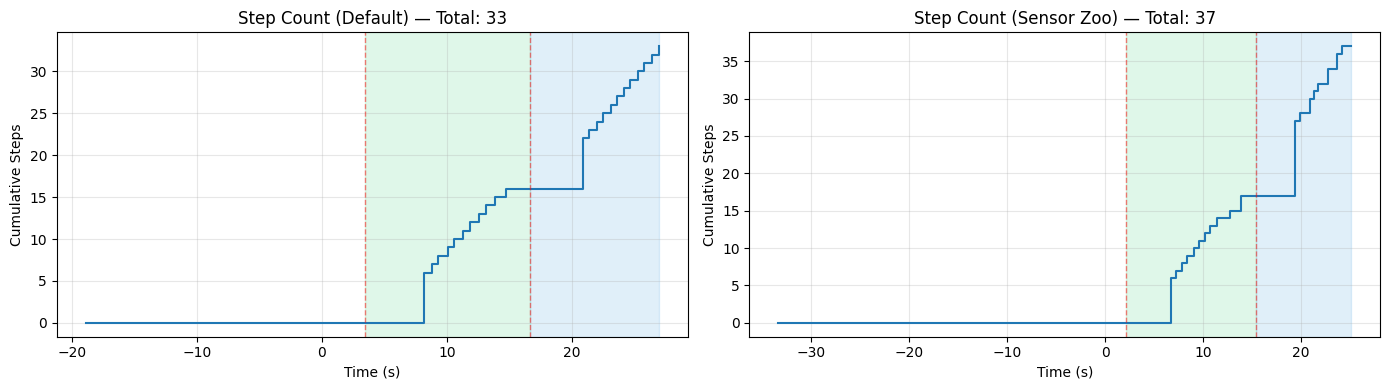

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

for ax, data, ann, label in [(ax1, default, ann_default, 'Default'), (ax2, zoo, ann_zoo, 'Sensor Zoo')]:
    df = data['Pedometer.csv']
    if df is not None:
        ax.step(df['seconds_elapsed'], df['steps'], where='post', linewidth=1.5)
        if ann:
            add_activity_shading(ax, ann, df['seconds_elapsed'].max())
        ax.set_title(f'Step Count ({label}) — Total: {df["steps"].max()}')
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Cumulative Steps')

plt.tight_layout()
plt.show()

## 9. Watch Sensors

Verify that watch data is synchronized and looks reasonable.

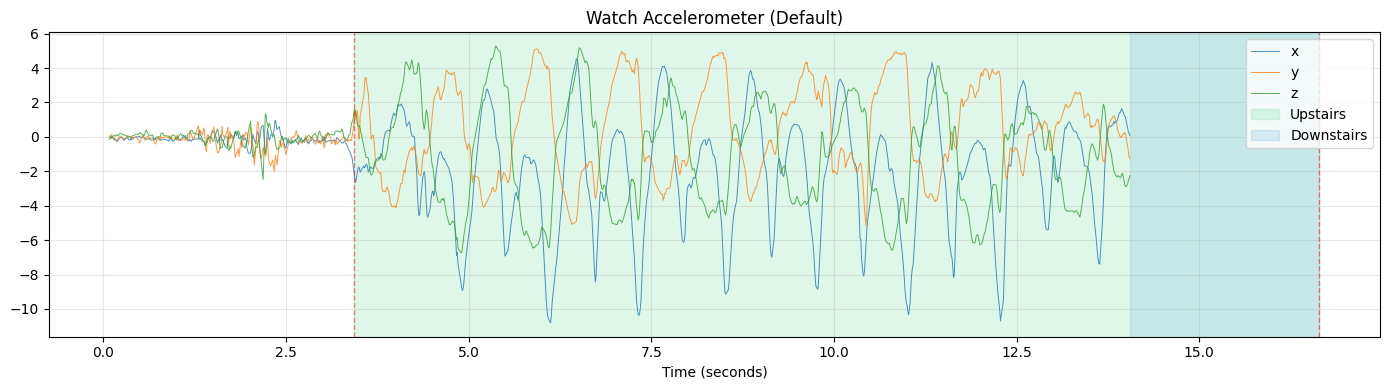

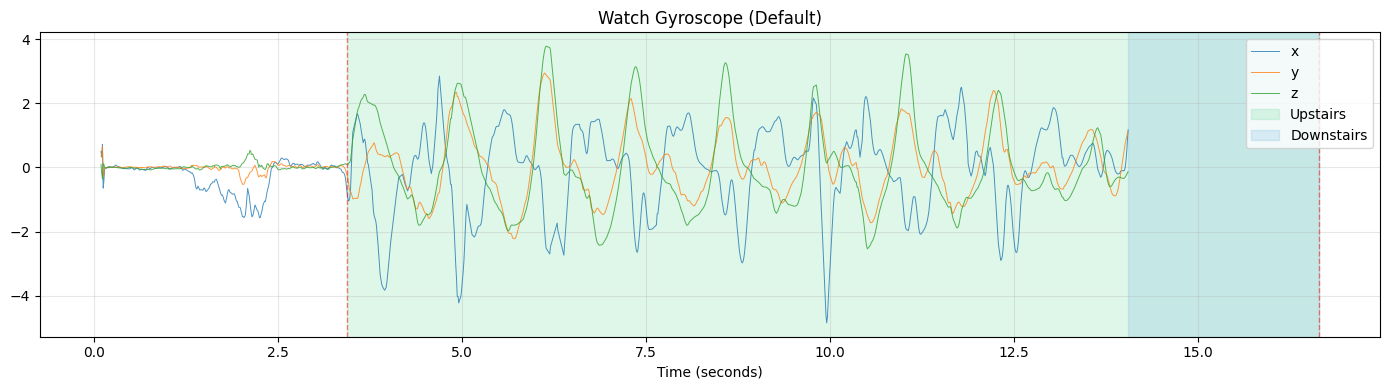

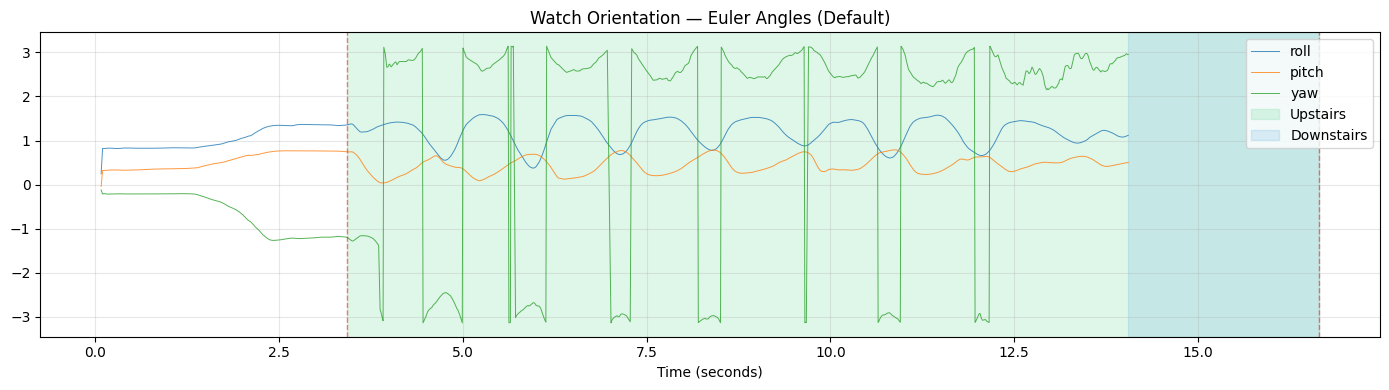

In [14]:
plot_xyz(default['WatchAccelerometer.csv'], 'Watch Accelerometer (Default)', ann_default)
plot_xyz(default['WatchGyroscope.csv'], 'Watch Gyroscope (Default)', ann_default)
plot_xyz(default['WatchOrientation.csv'], 'Watch Orientation — Euler Angles (Default)', ann_default, cols=['roll', 'pitch', 'yaw'])

## 10. Wi-Fi RSSI Scan

Check that all nearby APs are logged (not just the connected one).

In [15]:
wifi = default['WiFi.csv']
if wifi is not None:
    print(f'Total Wi-Fi scan entries: {len(wifi)}')
    print(f'Unique BSSIDs (access points): {wifi["BSSID"].nunique()}')
    print(f'Unique SSIDs (network names): {wifi["SSID"].nunique()}')
    print(f'Unique scan timestamps: {wifi["time"].nunique()}')
    print(f'\nAPs per scan (first scan):')
    first_scan_time = wifi['time'].iloc[0]
    first_scan = wifi[wifi['time'] == first_scan_time]
    print(f'  {len(first_scan)} APs detected')
    print(f'\nSample entries:')
    display(first_scan[['SSID', 'BSSID', 'level', 'frequency']].head(10))
else:
    print('No WiFi data found')

Total Wi-Fi scan entries: 22
Unique BSSIDs (access points): 22
Unique SSIDs (network names): 19
Unique scan timestamps: 1

APs per scan (first scan):
  22 APs detected

Sample entries:


,SSID,BSSID,level,frequency
0,Philly's Wifi 2.0,70:4f:57:8a:b8:87,-83,5200
1,TP-Link_8A60,5c:62:8b:cb:8a:5e,-84,5180
2,(hidden SSID),ca:42:a1:8f:b7:a6,-84,5200
3,Anaklysmos,b0:19:21:aa:09:3c,-65,2442
4,(hidden SSID),ee:07:1d:df:4d:bf,-88,5180
5,Anaklysmos,b0:19:21:aa:09:3b,-69,5240
6,Hollando internet,a8:42:a1:8f:b7:a7,-78,2452
7,DoloDenBoSanka,cc:32:e5:7c:29:53,-80,2417
8,POTUS,a8:42:a1:fc:86:99,-66,2462
9,Julia's huisje_EXT,cc:32:e5:8a:08:bc,-65,5500


## 11. Activity Detection (Sensor Logger built-in)

In [16]:
for label, data in [('Default', default), ('Sensor Zoo', zoo)]:
    act = data['Activity.csv']
    if act is not None and not act.empty:
        print(f'\n{label} — Activity Detection:')
        display(act)
    else:
        print(f'{label} — No activity data')


Default — Activity Detection:


,time,seconds_elapsed,activity
0,1775728160853000000,0.226,tilting
1,1775728160877000000,0.250,walking
2,1775728166087000000,5.460,unknown
3,1775728187186000000,26.559,cycling



Sensor Zoo — Activity Detection:


,time,seconds_elapsed,activity
0,1775728221311000000,0.289,unknown
1,1775728226312000000,5.290,unknown
2,1775728231316000000,10.294,unknown
3,1775728236383000000,15.361,unknown


## 12. Sampling Rate Check

Verify actual sampling rates match expected 100Hz.

In [17]:
def check_sampling_rate(df, name):
    """Calculate actual sampling rate from timestamps."""
    if df is None or len(df) < 2:
        return None
    dt = df['seconds_elapsed'].diff().dropna()
    mean_dt = dt.mean()
    actual_hz = 1.0 / mean_dt if mean_dt > 0 else 0
    return {'sensor': name, 'mean_interval_ms': mean_dt*1000, 'actual_Hz': round(actual_hz, 1), 'samples': len(df)}

key_sensors = ['Accelerometer.csv', 'Gyroscope.csv', 'Orientation.csv', 'Magnetometer.csv',
               'WatchAccelerometer.csv', 'WatchGyroscope.csv', 'WatchOrientation.csv', 'WatchBarometer.csv',
               'WatchMagnetometer.csv','Barometer.csv', 'Compass.csv']

print('=== Default Recording ===')
rates_d = [check_sampling_rate(default[s], s.replace('.csv','')) for s in key_sensors]
display(pd.DataFrame([r for r in rates_d if r is not None]).set_index('sensor'))

print('\n=== Sensor Zoo Recording ===')
rates_z = [check_sampling_rate(zoo[s], s.replace('.csv','')) for s in key_sensors]
display(pd.DataFrame([r for r in rates_z if r is not None]).set_index('sensor'))

=== Default Recording ===


,mean_interval_ms,actual_Hz,samples
sensor,,,
Accelerometer,18.558550,53.9,1536
Gyroscope,18.588845,53.8,1533
Orientation,19.158464,52.2,1486
Magnetometer,10.045872,99.5,2835
WatchAccelerometer,13.574711,73.7,1030
WatchGyroscope,13.538610,73.9,1032
WatchOrientation,13.857517,72.2,1009
WatchBarometer,100.638422,9.9,139
WatchMagnetometer,14.008538,71.4,996



=== Sensor Zoo Recording ===


,mean_interval_ms,actual_Hz,samples
sensor,,,
Accelerometer,18.548327,53.9,1415
Gyroscope,18.581123,53.8,1414
Orientation,18.581160,53.8,1413
Magnetometer,10.038226,99.6,2617
WatchAccelerometer,13.419557,74.5,1931
WatchGyroscope,13.440449,74.4,1928
WatchOrientation,13.864960,72.1,1869
WatchBarometer,100.581882,9.9,258
WatchMagnetometer,13.962127,71.6,1856
